# 2-stage coefficient-to-mask pipeline

This notebook trains the official two-stage system at five training-noise levels. Raw runs are stored under `output/stage_two/runs/`; grouped research artifacts are stored under `output/stage_two/`, and curated copies are published under `expected_output/stage_two/`. Predicted-coefficient IoU is the deployed metric; true-coefficient IoU remains diagnostic only.

## Architecture

The two-stage architecture is:

22 gradient features -> Stage 1 coefficient MLP -> predicted coefficient features -> Stage 2 coordinate-convolution decoder -> 32 x 32 mask logits.

Stage 1 is an MLP with hidden layers 256 -> 512 -> 256 and MSE coefficient loss. Stage 2 uses the same coordinate-convolution decoder family as the one-stage model: a dense projection into a 160 x 16 x 16 latent map, convolutional blocks, and coordinate channels before the final mask head.

Stage 2 is trained with BCE+Dice, rectangle boundary weighting, predicted-coefficient augmentation, Adam, dropout, and early stopping. Validation and official test data remain clean during training.

N is especially important here because it controls the coefficient representation. A Stage 1 coefficient error changes the input to Stage 2, so improving Stage 1 can improve Stage 2 disproportionately.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import torch

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from config.official import OFFICIAL_TRAIN_SIGMAS, official_two_stage_config
from datasets import build_two_stage_datasets
from experiments import (layer_table, load_two_stage_predictor, parameter_count, publish_expected_output, publish_run_artifacts)
from experiments.notebook import plot_history
from workflows.two_models import run_two_models
from models import Stage1Regressor
from pipeline.run import _build_stage2_model

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT = ROOT / 'output' / 'stage_two'
TRAIN_SIGMAS = OFFICIAL_TRAIN_SIGMAS
RUN_TRAINING = False

def make_config(train_sigma):
    return official_two_stage_config(train_sigma, output_root=ROOT / 'output')

stage1_check = Stage1Regressor(input_dim=22, output_dim=22, hidden_dims=(256, 512, 256), dropout_rates=(0.2, 0.2, 0.2))
print('Stage 1 parameters:', parameter_count(stage1_check))
print('Stage 2 parameters:', parameter_count(_build_stage2_model(make_config(0.001))))
layer_table(stage1_check, torch.zeros(2, 22))

Stage 1 parameters: {'total': 274454, 'trainable': 274454}
Stage 2 parameters: {'total': 43121603, 'trainable': 43121603}



=== training sigma=0 ===


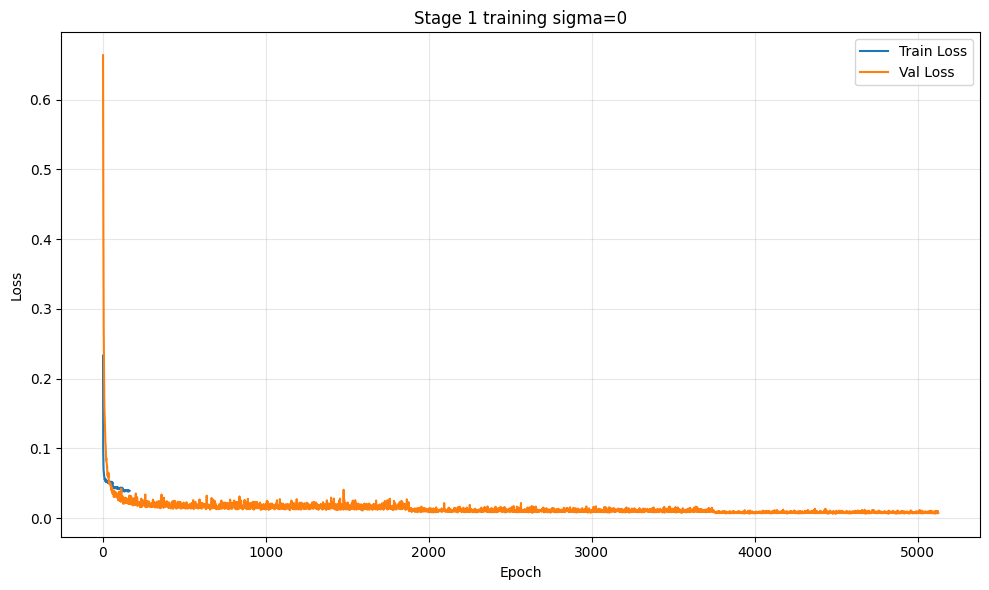

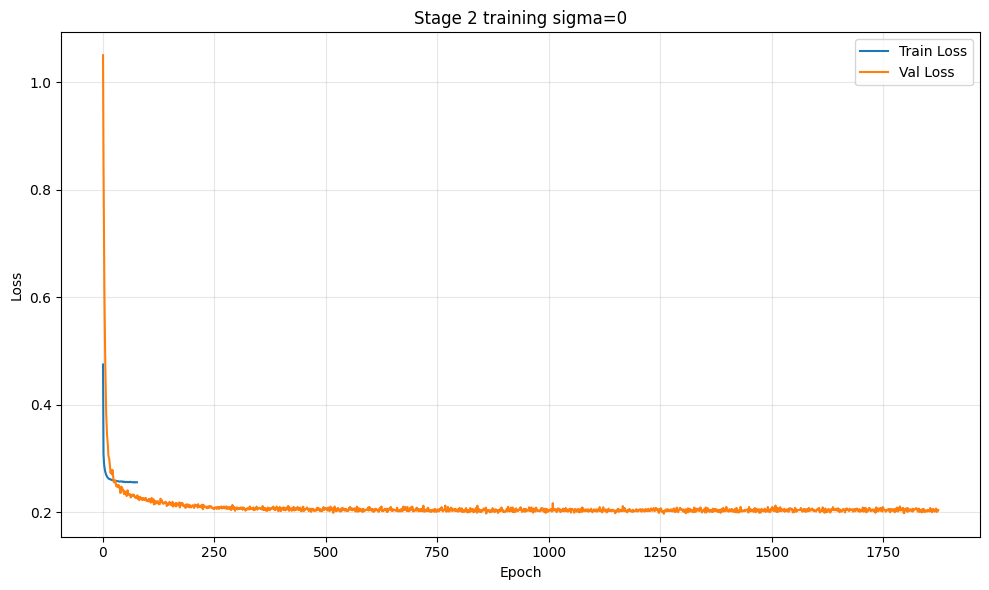

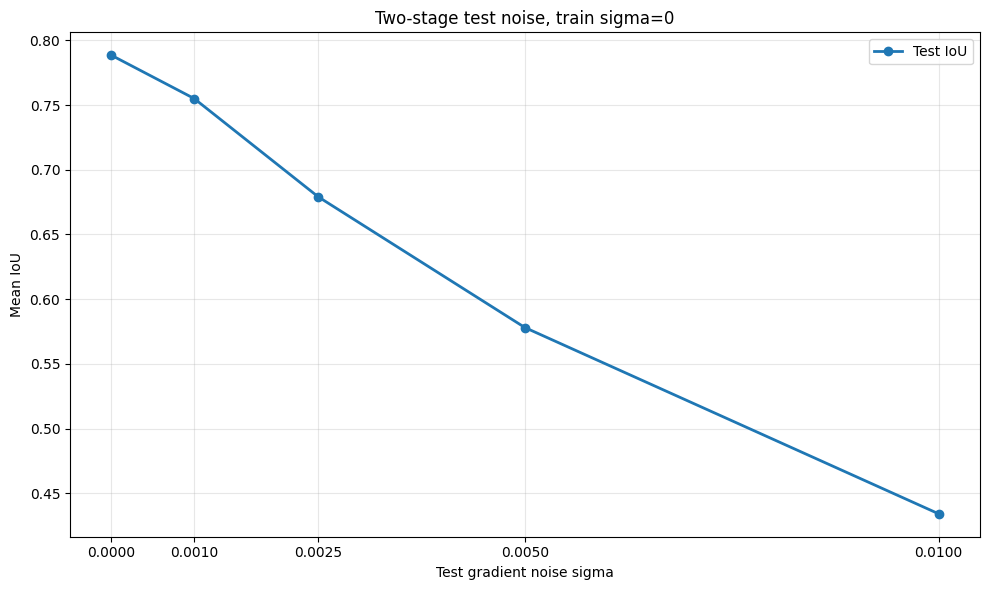

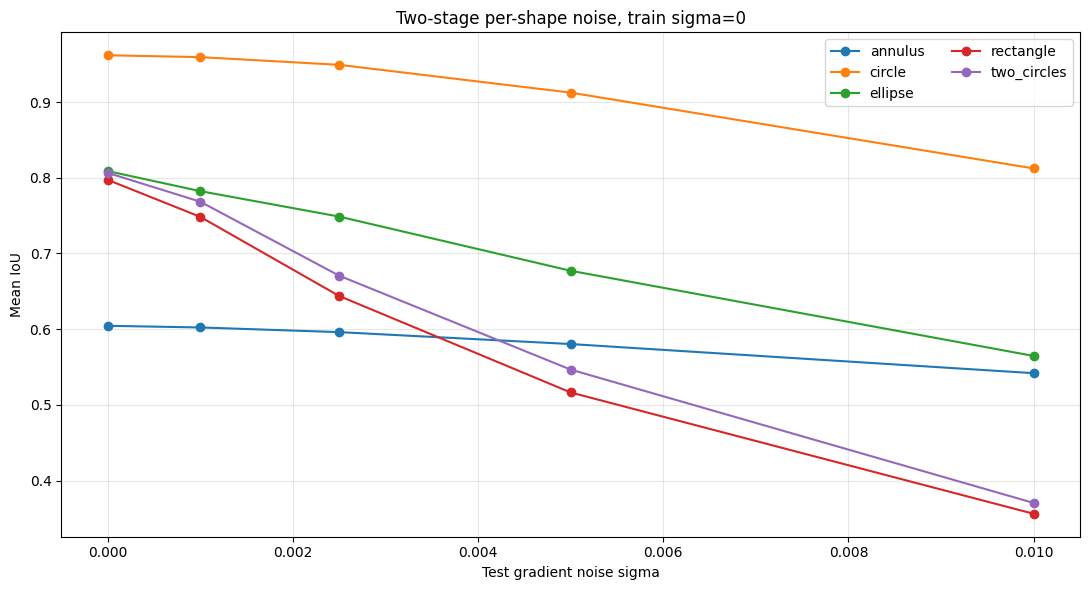


=== training sigma=0.001 ===


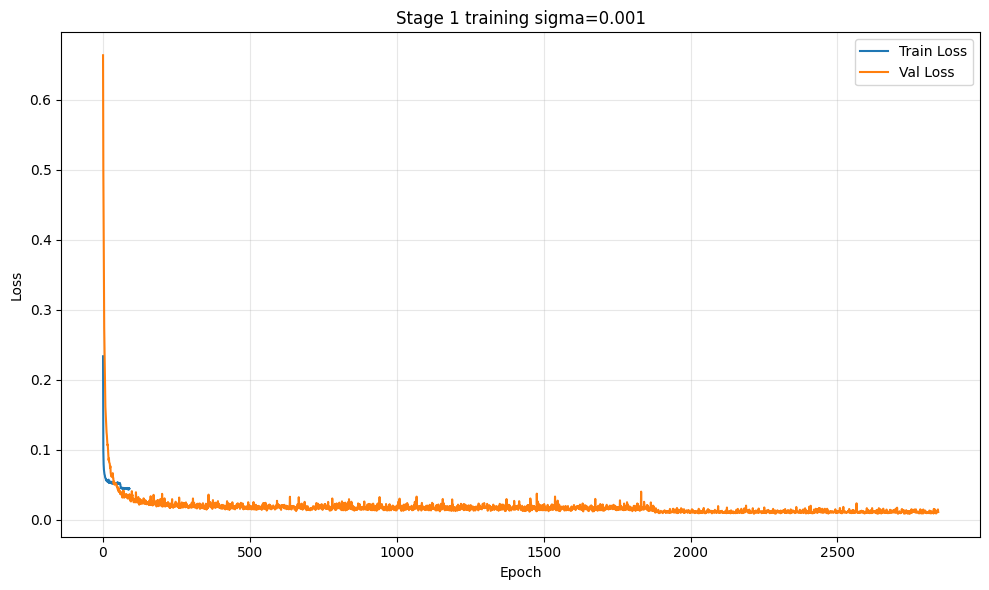

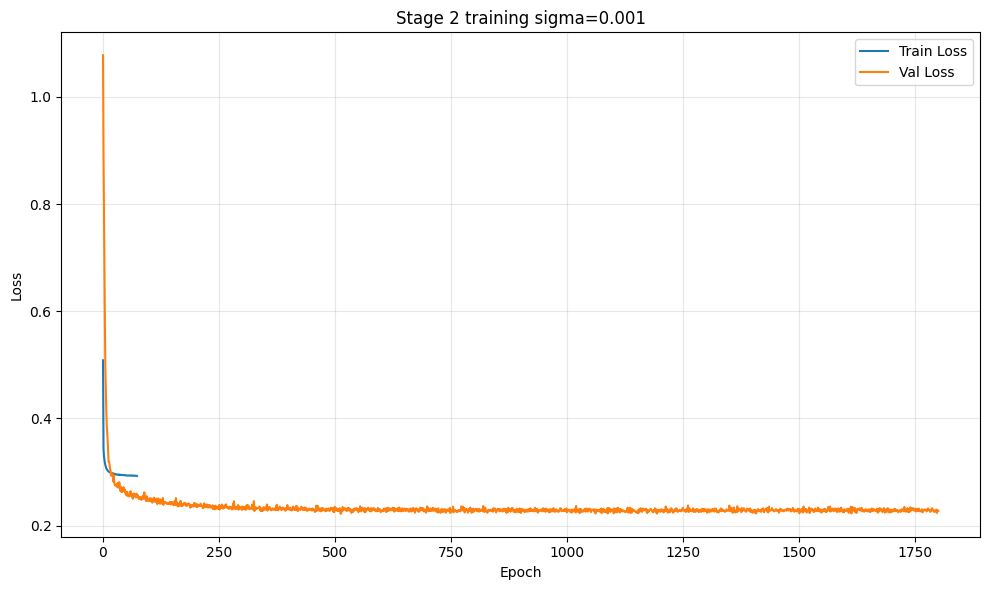

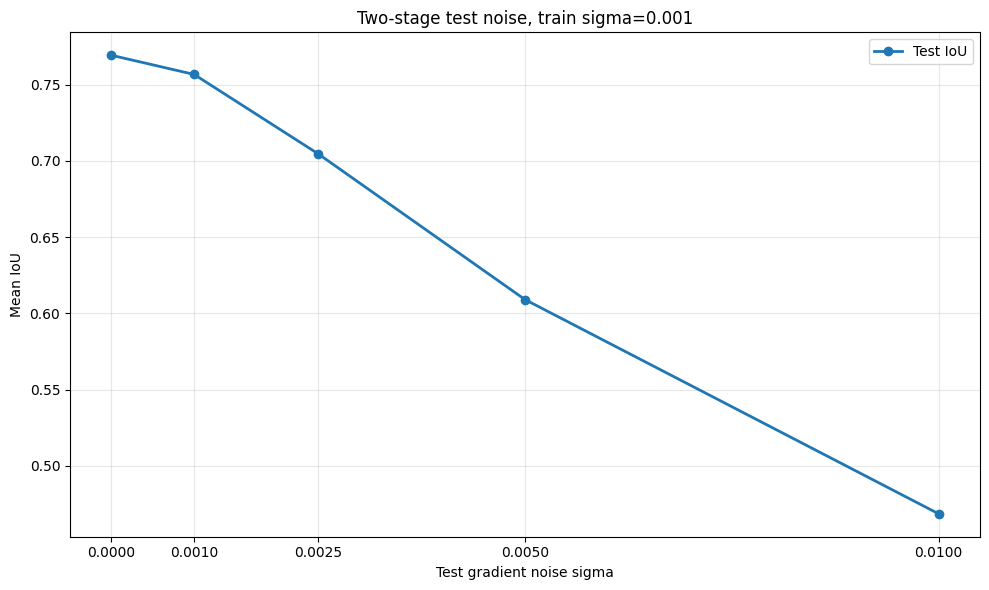

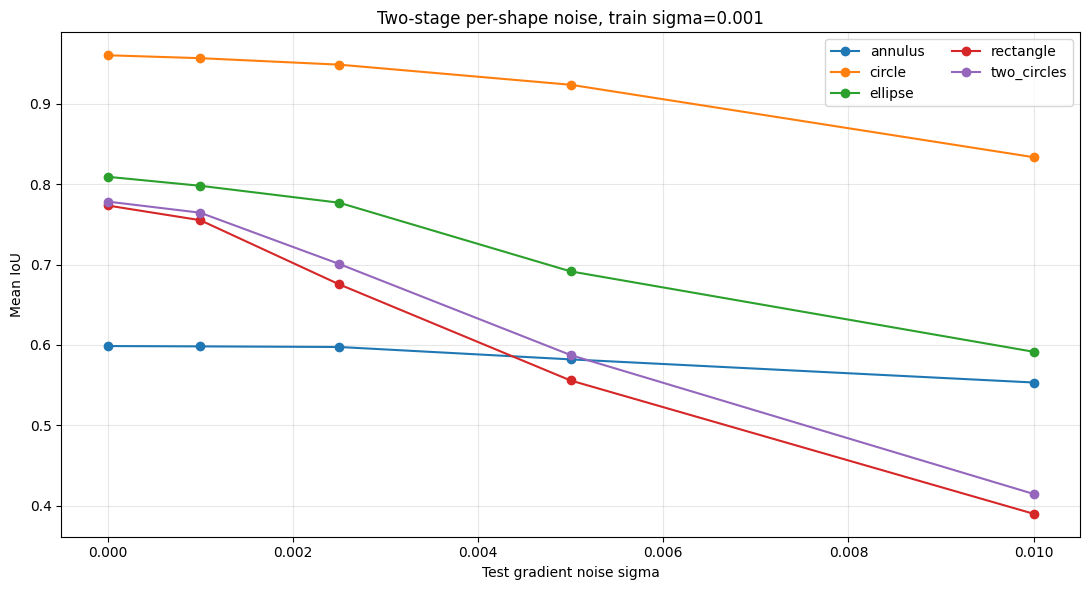


=== training sigma=0.0025 ===


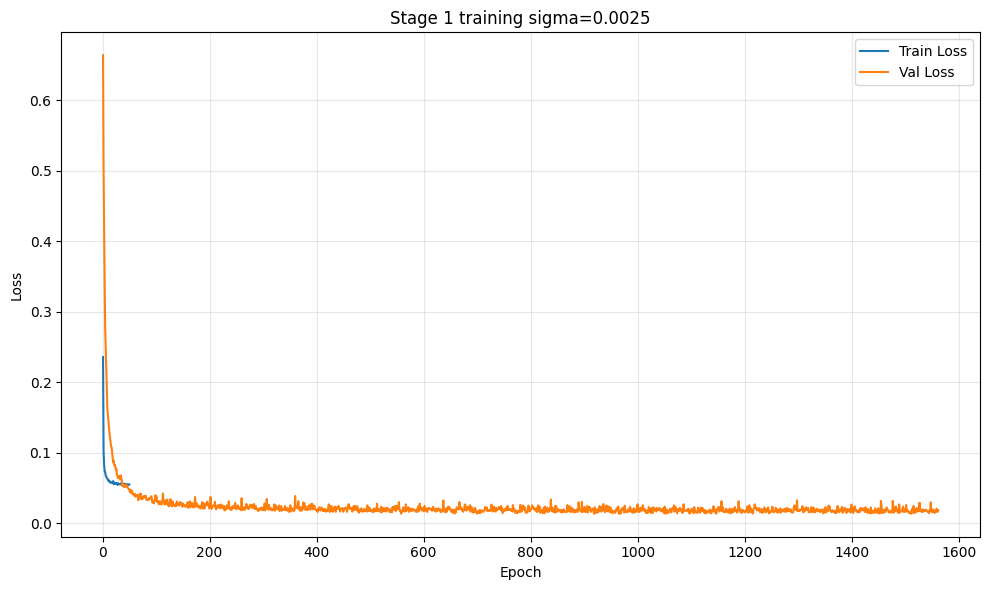

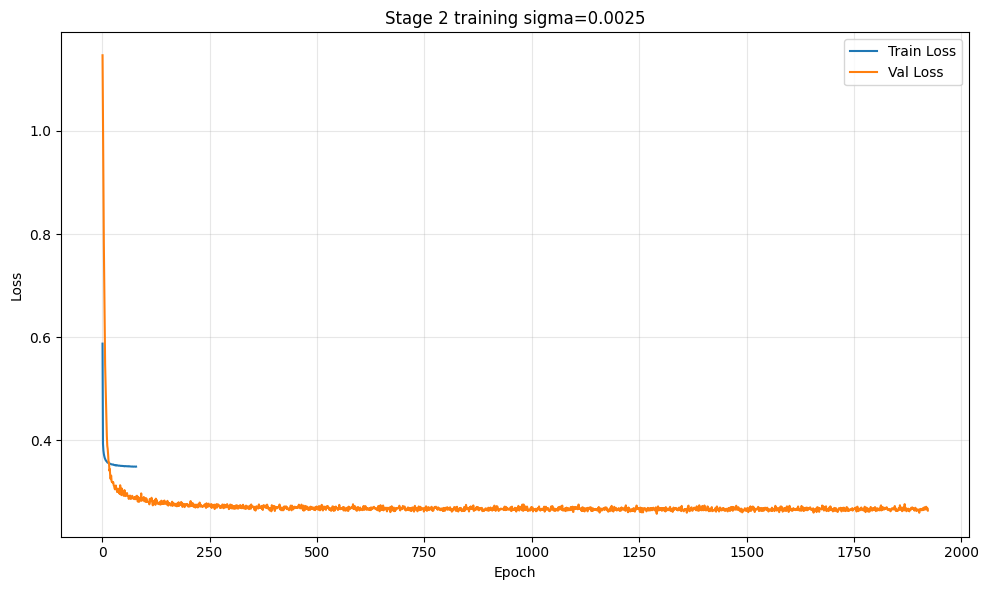

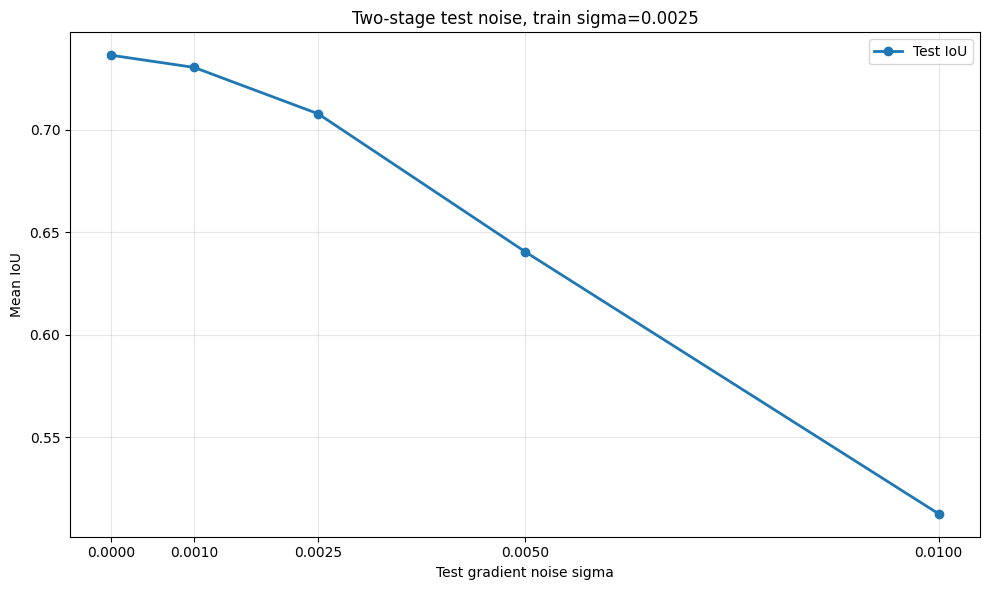

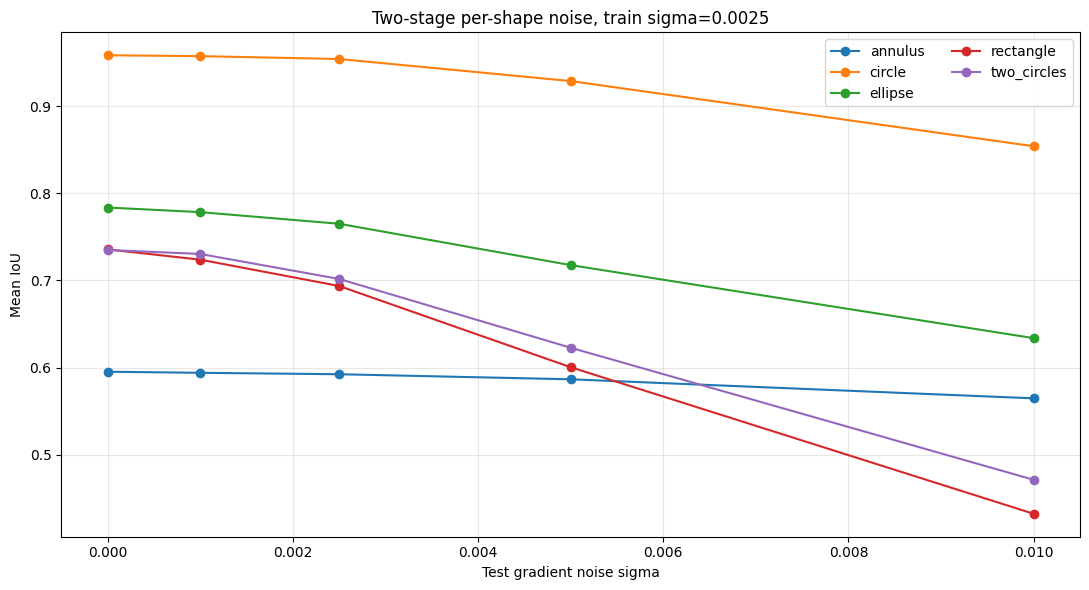


=== training sigma=0.005 ===


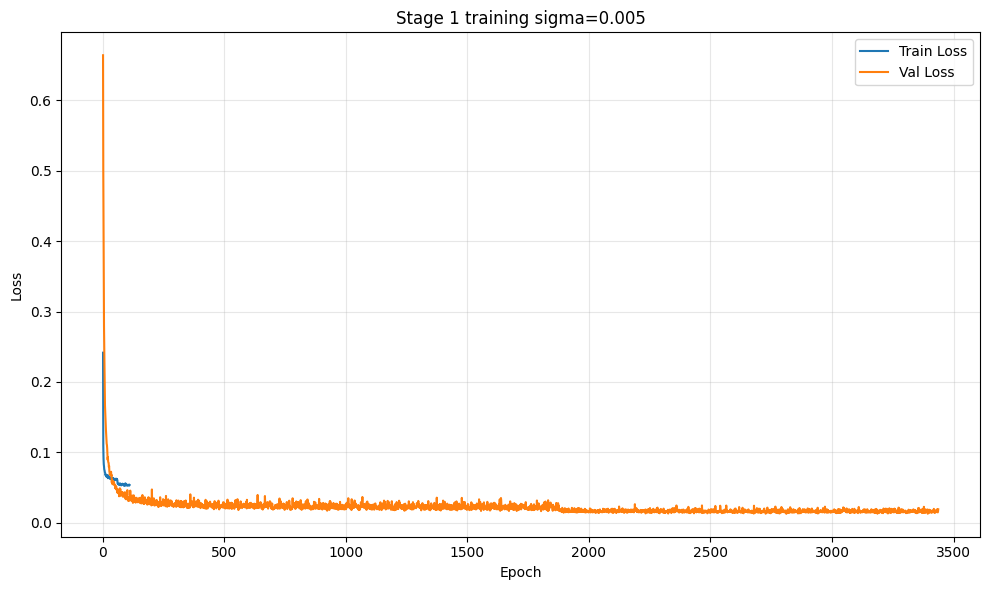

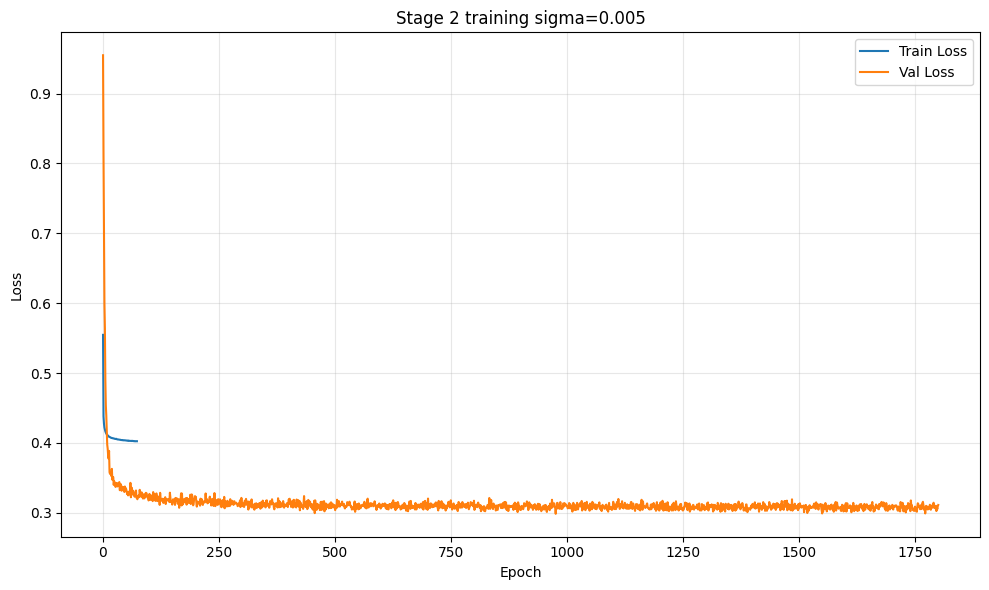

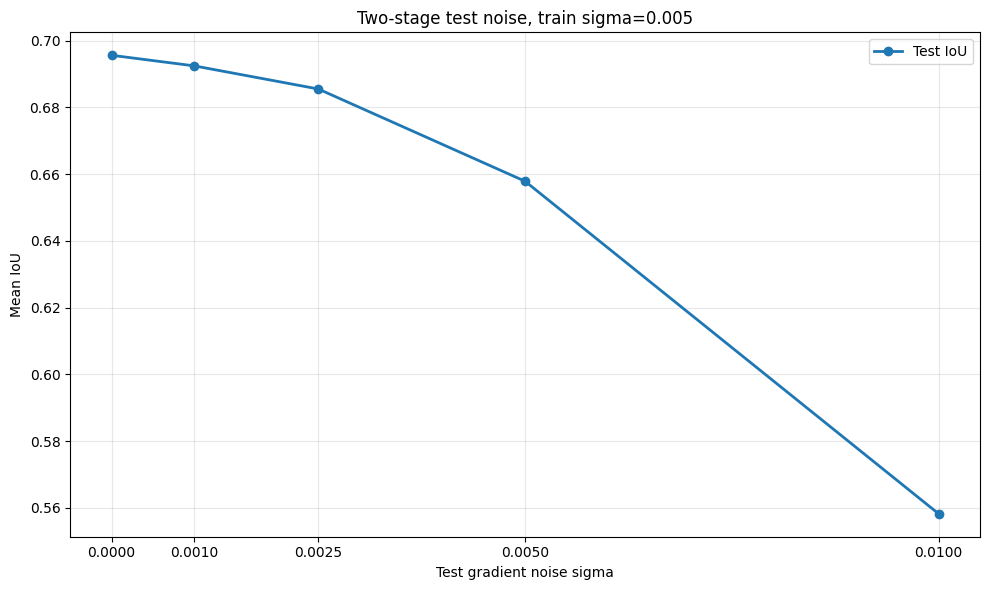

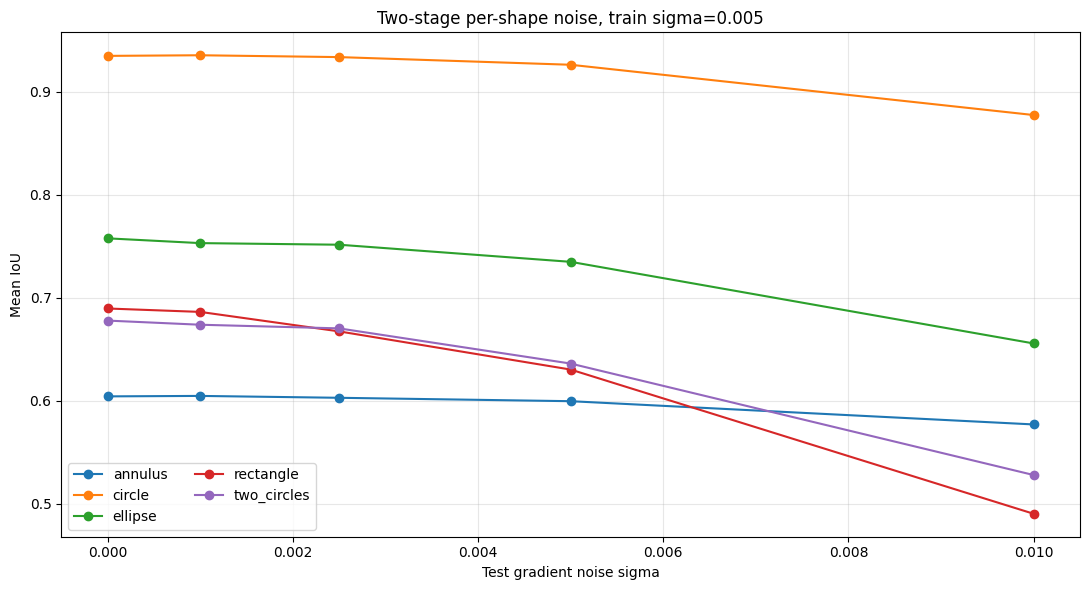


=== training sigma=0.01 ===


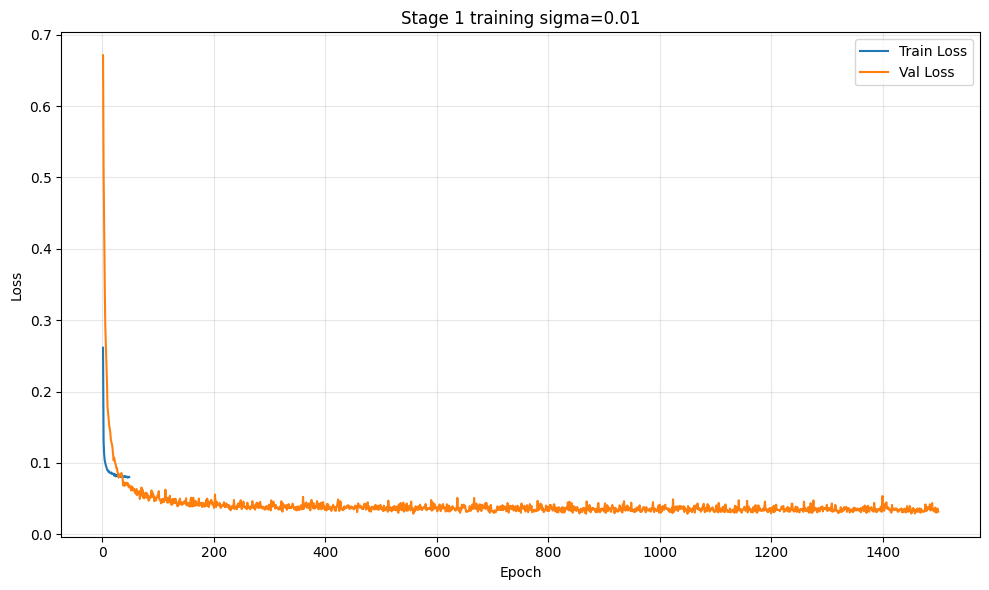

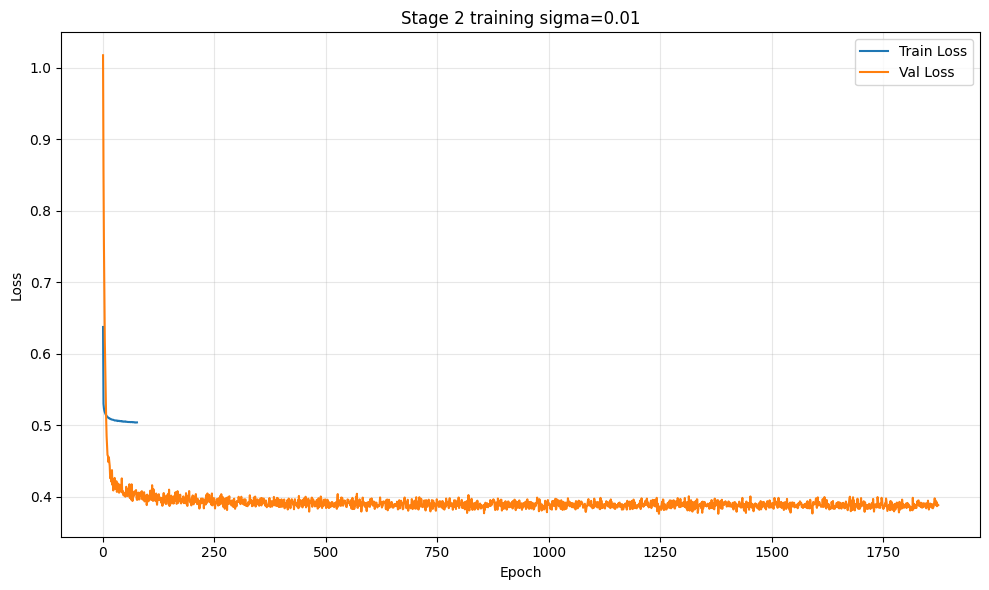

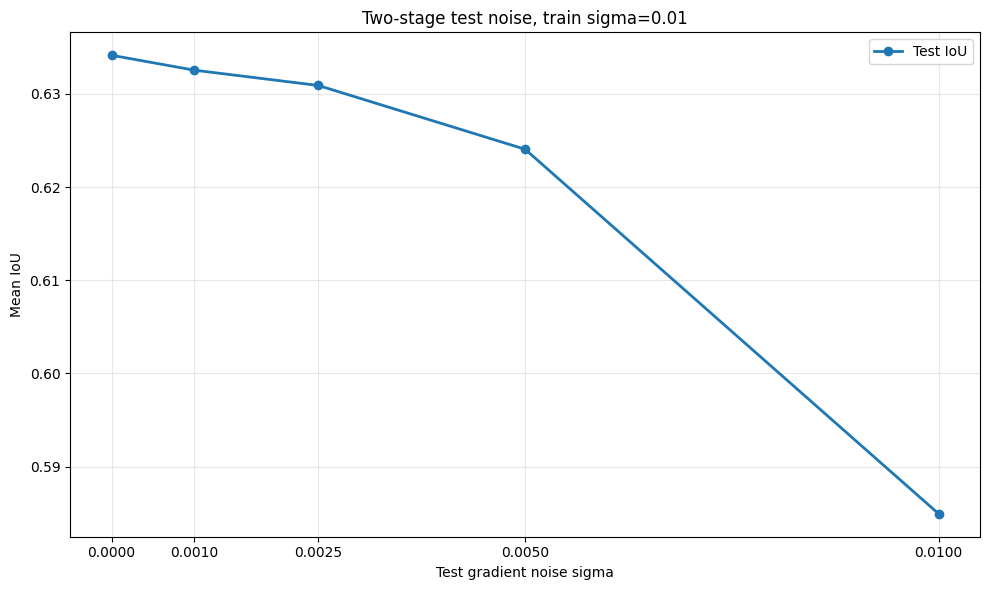

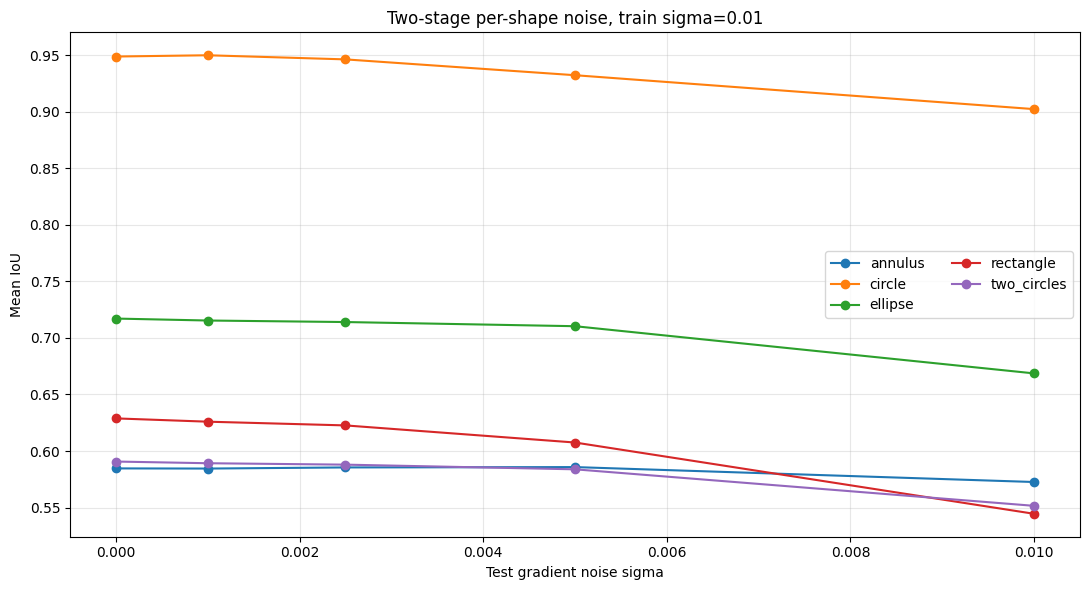

,train_sigma,clean_predicted_test_iou,clean_pixel_accuracy,threshold
0,0.0000,0.788459,0.979757,0.50
1,0.0010,0.769248,0.978572,0.45
2,0.0025,0.736281,0.975582,0.50
3,0.0050,0.695581,0.971387,0.45
4,0.0100,0.634146,0.963771,0.45


In [2]:
comparison_rows = []
for train_sigma in TRAIN_SIGMAS:
    config = make_config(train_sigma)
    summary_path = config.run_output_dir / 'summary.json'
    should_train = RUN_TRAINING or not summary_path.exists()
    print(f'\n=== training sigma={train_sigma:g} ===')
    summary = run_two_models(config, device=DEVICE) if should_train else json.loads(summary_path.read_text(encoding='utf-8'))
    bundle = build_two_stage_datasets(config)
    predict_logits, summary = load_two_stage_predictor(config.output_dir, config, DEVICE)
    threshold = float(summary['threshold_summary']['selected_threshold'])
    plot_history(summary['stage1_history'], config.run_output_dir / 'stage1_training_curves.png', f'Stage 1 training sigma={train_sigma:g}')
    plot_history(summary['stage2_history'], config.run_output_dir / 'stage2_training_curves.png', f'Stage 2 training sigma={train_sigma:g}')
    publish_run_artifacts('stage_two', config.run_output_dir, train_sigma, grouped_root=ROOT / 'output')
    clean = summary['metrics']['stage2_test']
    comparison_rows.append({'train_sigma': train_sigma, 'clean_predicted_test_iou': clean['mean_iou'], 'clean_pixel_accuracy': clean['pixel_accuracy'], 'threshold': threshold})
comparison = pd.DataFrame(comparison_rows)
publish_expected_output('stage_two', output_root=ROOT / 'output')
display(comparison)

Example artifact paths:

`output/stage_two/runs/train_sigma001/N_10/summary.json`

The `train_sigma...` directory also contains model weights, datasets, summaries, and training curves.